In [1]:
import uproot
import awkward as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
import vector

vector.register_awkward()
hep.style.use("CMS")

In [2]:
data_dir = "/home/tandrade/Flavour_Anomalies/Data/final_data_skim.root"
mc_b_dir = "/home/tandrade/Flavour_Anomalies/Data/final_mc_jpsi_skim.root"
mc_bu_dir = "/home/tandrade/Flavour_Anomalies/Data/final_mc_bu_skim.root"

tree_name = "tree_ML"

In [3]:
data_file = uproot.open(data_dir)
mc_b_file = uproot.open(mc_b_dir)
mc_bu_file = uproot.open(mc_bu_dir)

tree_data = data_file[tree_name]
tree_mc_bu = mc_bu_file[tree_name]
tree_mc_b = mc_b_file[tree_name]

In [4]:
for branche in tree_mc_b.keys():
    if "charge" in branche:
        print(branche)

MuMu_charge_good
Muon_tuneP_charge_l1_good
Muon_charge_l1_good
Muon_tuneP_charge_l2_good
Muon_charge_l2_good
BToTrkTrkMuMu_charge_l2_good
Track_charge_trk1_good
BToTrkTrkMuMu_charge_trk2_good
BToTrkTrkMuMu_charge_good
Track_charge_trk2_good
BToTrkTrkMuMu_charge_trk1_good
DiTrack_charge_good
BToTrkTrkMuMu_charge_l1_good


In [5]:
branches_to_load = [
    "BToTrkTrkMuMu_fit_l1_pt_good", "BToTrkTrkMuMu_fit_l1_eta_good", "BToTrkTrkMuMu_fit_l1_phi_good",
    "BToTrkTrkMuMu_fit_l2_pt_good", "BToTrkTrkMuMu_fit_l2_eta_good", "BToTrkTrkMuMu_fit_l2_phi_good",
    "BToTrkTrkMuMu_fit_trk1_pt_good", "BToTrkTrkMuMu_fit_trk1_eta_good", "BToTrkTrkMuMu_fit_trk1_phi_good",
    "BToTrkTrkMuMu_fit_trk2_pt_good", "BToTrkTrkMuMu_fit_trk2_eta_good", "BToTrkTrkMuMu_fit_trk2_phi_good",
    "Muon_genPartIdx_l1_good", "Muon_genPartIdx_l2_good",
    "GenPart_pdgId", 
    "Track_genPartFlav_trk1_good", "Track_genPartFlav_trk2_good",
    "Track_charge_trk1_good", "Track_charge_trk2_good", "HLT_DoubleMu4_3_LowMass", "BToTrkTrkMuMu_fit_mass_Kpi_good",
    "BToTrkTrkMuMu_charge_trk1_good", "BToTrkTrkMuMu_charge_trk2_good"
]

In [6]:
branches_to_load_data = branches_to_load = [
    "BToTrkTrkMuMu_fit_l1_pt_good", "BToTrkTrkMuMu_fit_l1_eta_good", "BToTrkTrkMuMu_fit_l1_phi_good",
    "BToTrkTrkMuMu_fit_l2_pt_good", "BToTrkTrkMuMu_fit_l2_eta_good", "BToTrkTrkMuMu_fit_l2_phi_good",
    "BToTrkTrkMuMu_fit_trk1_pt_good", "BToTrkTrkMuMu_fit_trk1_eta_good", "BToTrkTrkMuMu_fit_trk1_phi_good",
    "BToTrkTrkMuMu_fit_trk2_pt_good", "BToTrkTrkMuMu_fit_trk2_eta_good", "BToTrkTrkMuMu_fit_trk2_phi_good",
    "BToTrkTrkMuMu_charge_trk1_good", "BToTrkTrkMuMu_charge_trk2_good",
    
    "BToTrkTrkMuMu_l1_idx_good", "BToTrkTrkMuMu_l2_idx_good",
    "BToTrkTrkMuMu_trk1_idx_good", "BToTrkTrkMuMu_trk2_idx_good",
    "BToTrkTrkMuMu_ll_idx_good", "HLT_DoubleMu4_3_LowMass", "BToTrkTrkMuMu_fit_mass_Kpi_good",
    "BToTrkTrkMuMu_charge_trk1_good", "BToTrkTrkMuMu_charge_trk2_good"
]

In [7]:
data_branches = tree_data.arrays(branches_to_load_data, library="ak")
mc_bu_branches = tree_mc_bu.arrays(branches_to_load, library="ak")
mc_b_branches = tree_mc_b.arrays(branches_to_load, library="ak")

In [8]:
M_MU = 0.105658
M_K  = 0.493677
M_PI = 0.139570

In [9]:
p4_l1 = ak.zip({"pt": data_branches["BToTrkTrkMuMu_fit_l1_pt_good"], 
                "eta": data_branches["BToTrkTrkMuMu_fit_l1_eta_good"], 
                "phi": data_branches["BToTrkTrkMuMu_fit_l1_phi_good"], 
                "mass": M_MU}, 
               with_name="Momentum4D")

p4_l2 = ak.zip({"pt": data_branches["BToTrkTrkMuMu_fit_l2_pt_good"], 
                "eta": data_branches["BToTrkTrkMuMu_fit_l2_eta_good"], 
                "phi": data_branches["BToTrkTrkMuMu_fit_l2_phi_good"], 
                "mass": M_MU}, 
               with_name="Momentum4D")

p4_trk1 = ak.zip({"pt": data_branches["BToTrkTrkMuMu_fit_trk1_pt_good"], 
                  "eta": data_branches["BToTrkTrkMuMu_fit_trk1_eta_good"], 
                  "phi": data_branches["BToTrkTrkMuMu_fit_trk1_phi_good"], 
                  "mass": M_K}, 
                 with_name="Momentum4D")

p4_trk2 = ak.zip({"pt": data_branches["BToTrkTrkMuMu_fit_trk2_pt_good"],
                  "eta": data_branches["BToTrkTrkMuMu_fit_trk2_eta_good"], 
                  "phi": data_branches["BToTrkTrkMuMu_fit_trk2_phi_good"], 
                  "mass": M_PI}, 
                 with_name="Momentum4D")

In [10]:
dimuon = p4_l1 + p4_l2
kstar = p4_trk1 + p4_trk2
B = dimuon + kstar

jpsi_mask = (dimuon.mass > 2.9) & (dimuon.mass < 3.3)
trigger_mask = data_branches["HLT_DoubleMu4_3_LowMass"] == 1
total_mask = jpsi_mask & trigger_mask

B_filtered = B[total_mask]

In [11]:
B_mass = ak.flatten(data_branches["BToTrkTrkMuMu_fit_mass_Kpi_good"][total_mask])
B2_mass = ak.flatten(B_filtered.mass)

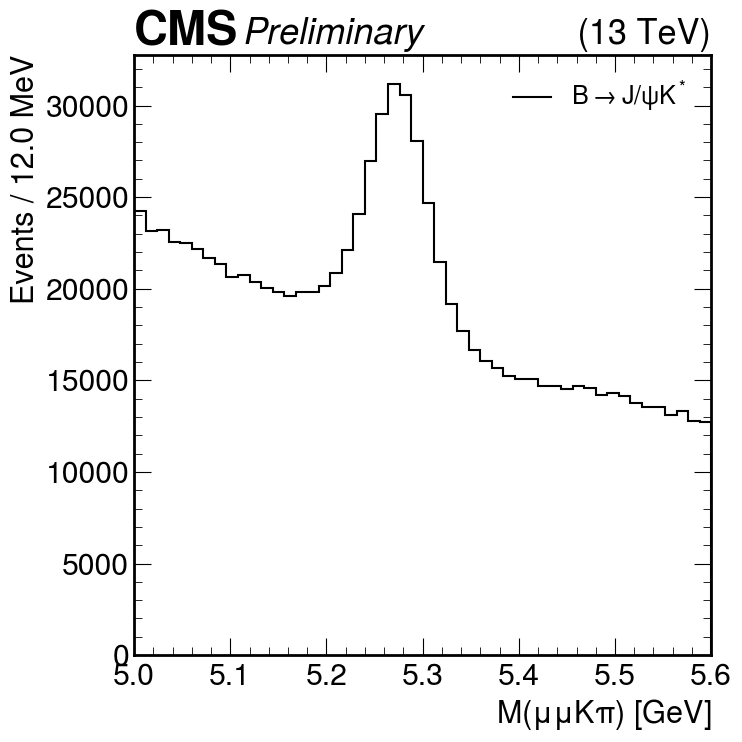

In [12]:
fig, ax = plt.subplots(figsize=(8, 8))

hep.cms.label("Preliminary", data=True, loc=0, ax=ax)
counts, bins = np.histogram(B2_mass, bins=50, range=(5.0, 5.6))

# Plotando com mplhep
hep.histplot(
    counts, 
    bins, 
    histtype='step', 
    color='black', 
    label=r'$B \to J/\psi K^*$', 
    ax=ax
)

# 3. Estilização dos Eixos
ax.set_xlabel(r'$M(\mu\mu K\pi)$ [GeV]', fontsize=22)
ax.set_ylabel(f'Events / {(bins[1]-bins[0])*1000:.1f} MeV', fontsize=22)
ax.set_xlim(5.0, 5.6)

# Legenda e Grid
ax.legend(loc='upper right', fontsize=18)
plt.tight_layout()

plt.show()

In [13]:
def get_b_mass(branches, m_l1=M_MU, m_l2=M_MU, m_t1=M_K, m_t2=M_PI):
    # Construção dos quadrivetores usando o pacote vector
    p4_l1 = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_l1_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_l1_eta_good"], 
                    "phi": branches["BToTrkTrkMuMu_fit_l1_phi_good"], "mass": m_l1}, with_name="Momentum4D")
    p4_l2 = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_l2_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_l2_eta_good"], 
                    "phi": branches["BToTrkTrkMuMu_fit_l2_phi_good"], "mass": m_l2}, with_name="Momentum4D")
    p4_trk1 = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_trk1_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_trk1_eta_good"], 
                      "phi": branches["BToTrkTrkMuMu_fit_trk1_phi_good"], "mass": m_t1}, with_name="Momentum4D")
    p4_trk2 = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_trk2_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_trk2_eta_good"], 
                      "phi": branches["BToTrkTrkMuMu_fit_trk2_phi_good"], "mass": m_t2}, with_name="Momentum4D")

    dimuon = p4_l1 + p4_l2
    B = dimuon + p4_trk1 + p4_trk2

    # Máscaras: J/psi mass window + Trigger
    jpsi_mask = (dimuon.mass > 2.9) & (dimuon.mass < 3.3)
    trigger_mask = branches["HLT_DoubleMu4_3_LowMass"] == 1
    total_mask = jpsi_mask & trigger_mask

    # Retorna a massa do B filtrada e planificada
    return ak.flatten(B.mass[total_mask])

# Processando as massas
mass_data = get_b_mass(data_branches)
mass_mc_bu = get_b_mass(mc_bu_branches)
mass_mc_b  = get_b_mass(mc_b_branches)

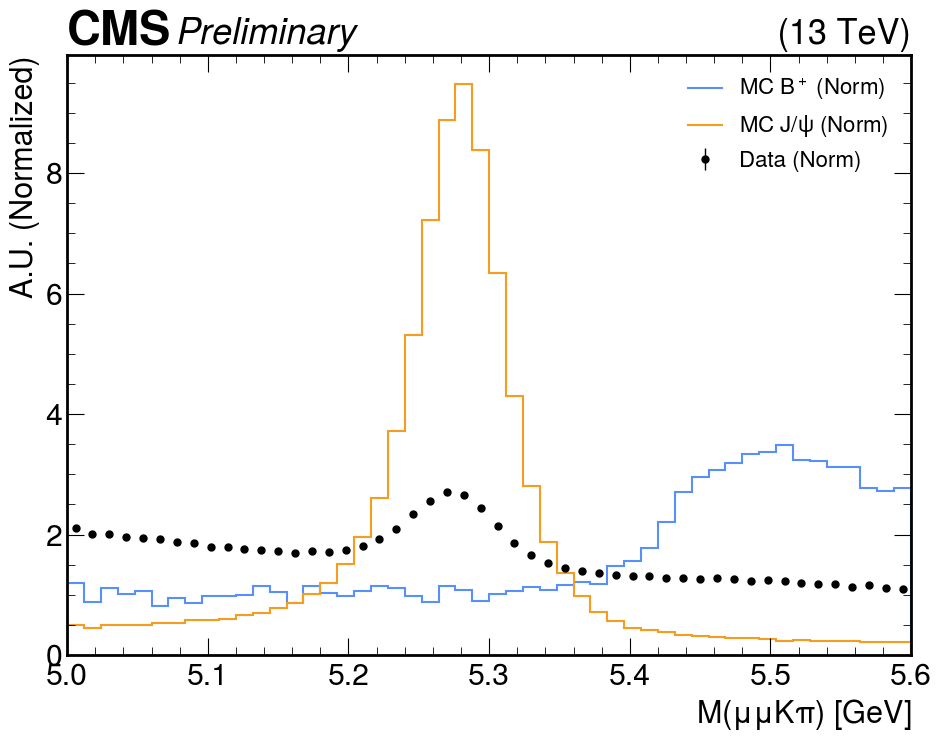

In [14]:
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt

# Configuração comum de binagem
bin_config = {"bins": 50, "range": (5.0, 5.6)}

fig, ax = plt.subplots(figsize=(10, 8))
hep.cms.label("Preliminary", data=True, loc=0, ax=ax)

# 1. DATA: Histograma com erro estatístico (Normalizado)
counts_data, bins = np.histogram(mass_data, **bin_config)
# Calculando densidade manualmente para o erro: densidade = counts / (N * bin_width)
bin_width = bins[1] - bins[0]
density_data = counts_data / (np.sum(counts_data) * bin_width)
errors_data = np.sqrt(counts_data) / (np.sum(counts_data) * bin_width)

hep.histplot(
    density_data, 
    bins, 
    yerr=errors_data, 
    histtype='errorbar', 
    color='black', 
    label='Data (Norm)', 
    ax=ax
)

# 2. MC Bu: Normalizado
counts_bu, _ = np.histogram(mass_mc_bu, **bin_config)
density_bu = counts_bu / (np.sum(counts_bu) * bin_width)

hep.histplot(
    density_bu, 
    bins, 
    histtype='step', 
    label=r'MC $B^+$ (Norm)', 
    ax=ax
)

# 3. MC J/psi: Normalizado
counts_b, _ = np.histogram(mass_mc_b, **bin_config)
density_b = counts_b / (np.sum(counts_b) * bin_width)

hep.histplot(
    density_b, 
    bins, 
    histtype='step', 
    label=r'MC $J/\psi$ (Norm)', 
    ax=ax
)

# --- Estilização ---
ax.set_xlabel(r'$M(\mu\mu K\pi)$ [GeV]', fontsize=22)
ax.set_ylabel('A.U. (Normalized)', fontsize=22)
ax.set_xlim(5.0, 5.6)
ax.legend(loc='upper right', fontsize=16)

plt.tight_layout()
plt.show()

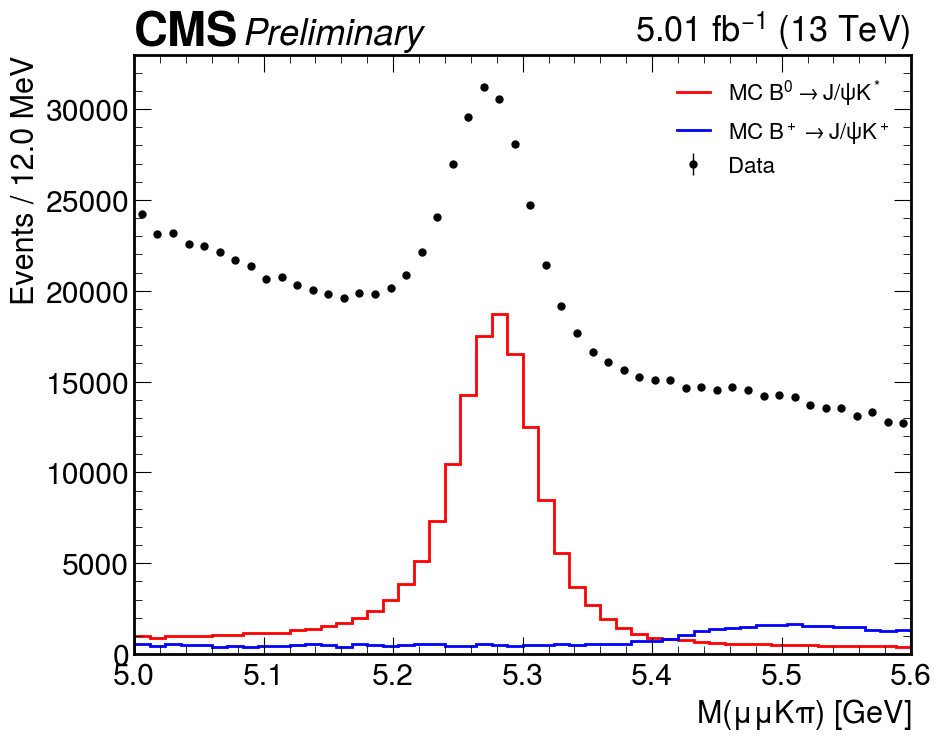

In [15]:
# --- Parâmetros de Entrada ---
lumi_data = 5010  # 5.01 fb^-1 em pb^-1

# MC_B (J/psi K*)
sigma_b = 13800000.0 
br_b = 5.07e-5
n_gen_b = 3257972
weight_b = (sigma_b * br_b * lumi_data) / n_gen_b

# MC_Bu (B+ -> J/psi K+)
sigma_bu = 39590000.0
br_bu = 1.01e-3 * 0.0596  # PDG B+ -> J/psi K+ vezes J/psi -> mumu
n_gen_bu = 3921328
weight_bu = (sigma_bu * br_bu * lumi_data) / n_gen_bu

# --- Obtenção das massas ---
# Assumindo que a função get_b_mass foi definida conforme discutido
mass_data = get_b_mass(data_branches)
mass_mc_b = get_b_mass(mc_b_branches)
mass_mc_bu = get_b_mass(mc_bu_branches)

# --- Plotagem ---
fig, ax = plt.subplots(figsize=(10, 8))
hep.cms.label("Preliminary", data=True, lumi=5.01, loc=0, ax=ax)

bin_config = {"bins": 50, "range": (5.0, 5.6)}

# 1. Plot Data (Pontos Pretos)
counts_data, bins = np.histogram(mass_data, **bin_config)
hep.histplot(counts_data, bins, histtype='errorbar', color='black', label='Data', ax=ax)

# 2. Plot MC B (Sinal J/psi K*)
counts_b, _ = np.histogram(mass_mc_b, **bin_config)
hep.histplot(counts_b * weight_b, bins, histtype='step', 
             color='red', linewidth=2, label=r'MC $B^0 \to J/\psi K^*$', ax=ax)

# 3. Plot MC Bu (Fundo B+ -> J/psi K+)
counts_bu, _ = np.histogram(mass_mc_bu, **bin_config)
hep.histplot(counts_bu * weight_bu, bins, histtype='step', 
             color='blue', linewidth=2, label=r'MC $B^+ \to J/\psi K^+$', ax=ax)

# --- Ajustes Finais ---
ax.set_xlabel(r'$M(\mu\mu K\pi)$ [GeV]', fontsize=22)
ax.set_ylabel(f'Events / {(bins[1]-bins[0])*1000:.1f} MeV', fontsize=22)
ax.set_xlim(5.0, 5.6)
ax.legend(loc='upper right', fontsize=16)

plt.tight_layout()
plt.show()

In [16]:
def get_m_mumuK_correlations(branches):
    # Quadrivetores básicos
    p4_l1 = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_l1_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_l1_eta_good"], 
                    "phi": branches["BToTrkTrkMuMu_fit_l1_phi_good"], "mass": M_MU}, with_name="Momentum4D")
    p4_l2 = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_l2_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_l2_eta_good"], 
                    "phi": branches["BToTrkTrkMuMu_fit_l2_phi_good"], "mass": M_MU}, with_name="Momentum4D")
    
    # Track 1 e Track 2 (ambas testadas como Kaon)
    p4_trk1_K = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_trk1_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_trk1_eta_good"], 
                        "phi": branches["BToTrkTrkMuMu_fit_trk1_phi_good"], "mass": M_K}, with_name="Momentum4D")
    p4_trk2_K = ak.zip({"pt": branches["BToTrkTrkMuMu_fit_trk2_pt_good"], "eta": branches["BToTrkTrkMuMu_fit_trk2_eta_good"], 
                        "phi": branches["BToTrkTrkMuMu_fit_trk2_phi_good"], "mass": M_K}, with_name="Momentum4D")

    dimuon = p4_l1 + p4_l2
    
    # Seleção de cargas para identificar K+ e K-
    # trk1 é K+ se carga for 1, trk2 é K- se carga for -1 (ajuste conforme seu ntuple)
    mask_trk1_pos = branches["BToTrkTrkMuMu_charge_trk1_good"] == 1
    mask_trk2_neg = branches["BToTrkTrkMuMu_charge_trk2_good"] == -1
    
    # Cálculo das massas m(mumuK)
    m_mumuKp = (dimuon + p4_trk1_K).mass
    m_mumuKm = (dimuon + p4_trk2_K).mass

    # Aplicação do corte de J/psi e Trigger (Pre-selection)
    jpsi_mask = (dimuon.mass > 2.9) & (dimuon.mass < 3.3)
    trigger_mask = branches["HLT_DoubleMu4_3_LowMass"] == 1
    total_mask = jpsi_mask & trigger_mask

    return ak.flatten(m_mumuKp[total_mask]), ak.flatten(m_mumuKm[total_mask])

# Processando
mKp_data, mKm_data = get_m_mumuK_correlations(data_branches)
mKp_bu, mKm_bu = get_m_mumuK_correlations(mc_bu_branches)

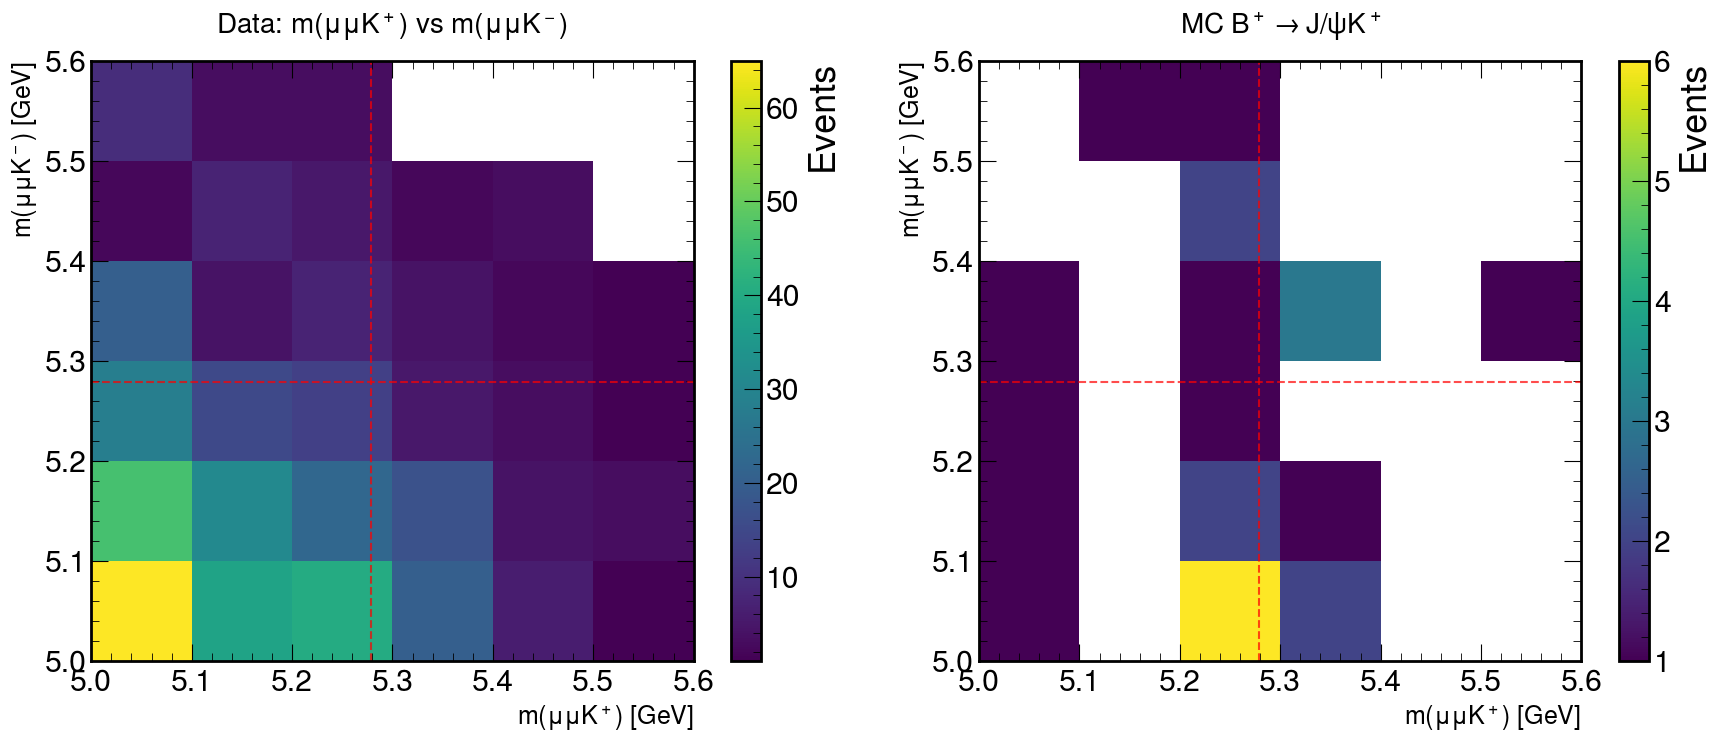

In [20]:
# --- Conversão explícita para NumPy para evitar conflitos com o Matplotlib ---
mKp_data_np = ak.to_numpy(mKp_data)
mKm_data_np = ak.to_numpy(mKm_data)

mKp_bu_np = ak.to_numpy(mKp_bu)
mKm_bu_np = ak.to_numpy(mKm_bu)

# --- Plotagem ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Parâmetros de plotagem ajustados
plot_kwargs = {
    "bins": 6,
    "range": [[5.0, 5.6], [5.0, 5.6]],
    "cmap": "viridis",
    "cmin": 1  # Isso esconde bins vazios
}

# --- Plot 1: DATA ---
# Usando os arrays convertidos para numpy
h1 = ax1.hist2d(mKp_data_np, mKm_data_np, **plot_kwargs)
ax1.set_title("Data: $m(\mu\mu K^+)$ vs $m(\mu\mu K^-)$", fontsize=20, pad=20)
fig.colorbar(h1[3], ax=ax1, label='Events')

# --- Plot 2: MC Bu ---
h2 = ax2.hist2d(mKp_bu_np, mKm_bu_np, **plot_kwargs)
ax2.set_title(r"MC $B^+ \to J/\psi K^+$", fontsize=20, pad=20)
fig.colorbar(h2[3], ax=ax2, label='Events')

# Linhas de referência e estilo
for ax in [ax1, ax2]:
    ax.set_xlabel(r"$m(\mu\mu K^+)$ [GeV]", fontsize=18)
    ax.set_ylabel(r"$m(\mu\mu K^-)$ [GeV]", fontsize=18)
    # Linha na massa do B+ (PDG 5.279)
    ax.axhline(5.279, color='red', linestyle='--', alpha=0.7, label='B Mass')
    ax.axvline(5.279, color='red', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()